<a href="https://colab.research.google.com/github/Qunzh/CAN_GridCell_Model/blob/main/Ring_Model_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [252]:
#Ring Model

def ring_model(epsilon, theta_cue, A, c, n_number, tau, J_0, J_2, dt, total_t, theta_0, a):
# Parameters for thalamic(LGN) input: epsilon = tuning, theta_cue = peak preferred orientation, c = contrast, A = amplitude
# Parameters for V1: n_number = total number of neurons, tau = time constant, J_0 = recurrent inhibition weight, J_2 = recurrent excitation weight
# Parameters for time: dt = length of timestep, total_t = total integration time
# Parameters for initial conditions: theta_0 = initial tuned orientation of V1, a = initial rate amplitude of V1

  # Initialization
  t_steps = int(total_t/dt)
  rate = np.zeros((t_steps, n_number))
  I_theta = np.zeros((t_steps, n_number))
  recurrent = np.zeros((t_steps, n_number))
  h_theta = np.zeros((n_number))

  # Neuron Label
  theta_i = np.zeros((n_number))
  for i in range(0, n_number):
    theta_i[i] = (np.pi/n_number) * i - np.pi/2

  # Intial Conditions
  for i in range(0, n_number):
    rate[0, i] = a * np.cos(2 * (theta_i[i] - theta_0))

  # Thalamic input
  for i in range(0, n_number):
    h_theta[i] = A * c * (1 - epsilon + epsilon * np.cos(2 * (theta_i[i] - theta_cue)))

  # Pre-compute connectivity matrix
  theta_diff = theta_i[:, np.newaxis] - theta_i[np.newaxis, :]
  W = (J_0 + J_2 * np.cos(2 * theta_diff)) * (np.pi / n_number)

  # Time integration
  for t in range(1, t_steps):
    # Vectorized recurrent calculation
    recurrent[t, :] = W @ rate[t-1, :]

    # Total input
    I_theta[t, :] = h_theta + recurrent[t, :]

    # Rectification
    I_theta[t, :] = np.maximum(I_theta[t, :], 0)

    # Euler integration
    drdt = (-rate[t-1, :] + I_theta[t-1, :]) / tau
    rate[t, :] = rate[t-1, :] + drdt * dt

  steady_state = rate[t, :]
  return theta_i, steady_state, W

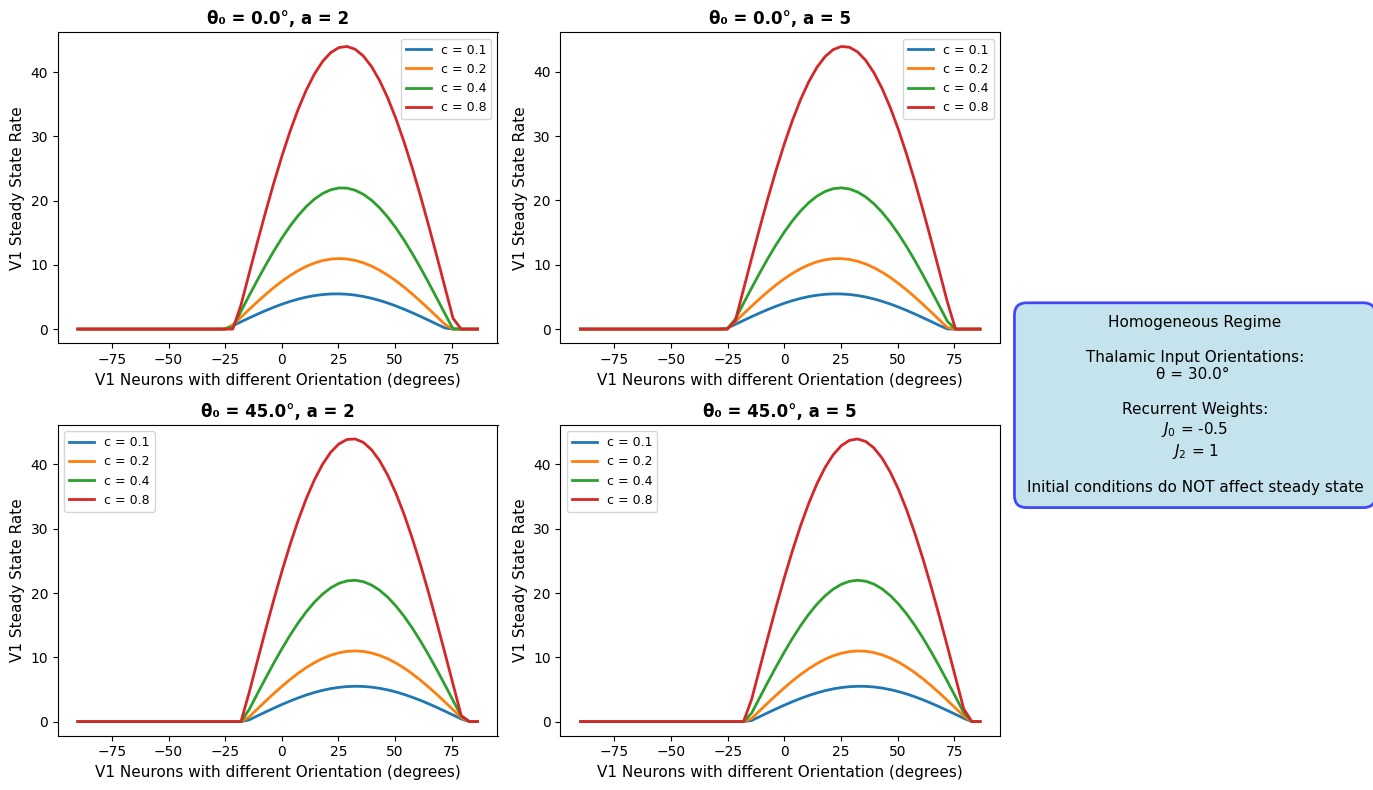

In [273]:
# Homogeneous regime (with small recurrent excitation J_2 and small recurrent inhibition J_0)
J_0, J_2 = -0.5, 1
theta_cue = np.pi/6
contrast_values = [0.1, 0.2, 0.4, 0.8]
theta_0_values = [0, np.pi/4]
a_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, theta_0 in enumerate(theta_0_values):
    for idx_1, a in enumerate(a_values):
        ax = axes[idx, idx_1]

        for c in contrast_values:
            theta_i, steady_state, W = ring_model(0.1, theta_cue, 40, c, 50, 10, J_0, J_2, 0.01, 200, theta_0, a)
            ax.plot(np.rad2deg(theta_i), steady_state, label=f'c = {c}', linewidth=2)

        ax.set_xlabel('V1 Neurons with different Orientation (degrees)', fontsize=11)
        ax.set_ylabel('V1 Steady State Rate', fontsize=11)
        ax.set_title(f'θ₀ = {np.rad2deg(theta_0):.1f}°, a = {a}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)

textstr = f'Homogeneous Regime\n \n Thalamic Input Orientations: \nθ = {np.rad2deg(theta_cue):.1f}° \n \nRecurrent Weights:\n$J_0$ = {J_0}\n$J_2$ = {J_2}\n\nInitial conditions do NOT affect steady state'
props = dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.7, edgecolor='blue', linewidth=2)

fig.text(1, 0.6, textstr, transform=fig.transFigure, fontsize=11,
         verticalalignment='top', horizontalalignment='center', bbox=props)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

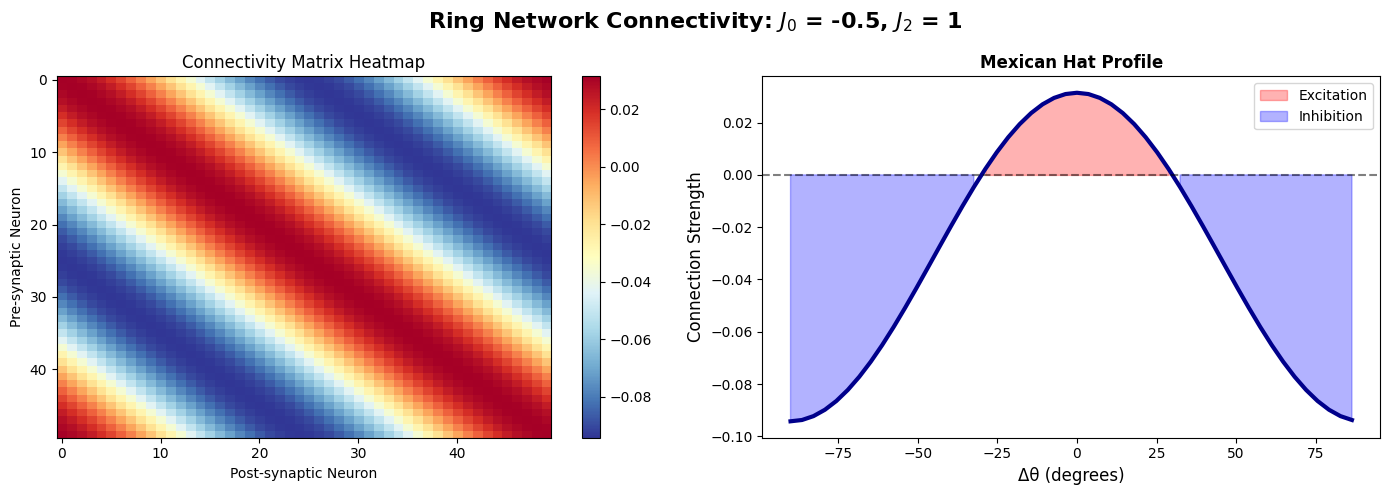

In [280]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Heatmap
n_number = 50
im = axes[0].imshow(W, cmap='RdYlBu_r', aspect='auto')
axes[0].set_xlabel('Post-synaptic Neuron')
axes[0].set_ylabel('Pre-synaptic Neuron')
axes[0].set_title('Connectivity Matrix Heatmap')
plt.colorbar(im, ax=axes[0])

# Right: Profile showing Mexican hat
center = n_number // 2
axes[1].plot(np.rad2deg(theta_i), W[center, :], linewidth=3, color='darkblue')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1].fill_between(np.rad2deg(theta_i), 0, W[center, :],
                      where=(W[center, :] > 0), alpha=0.3, color='red', label='Excitation')
axes[1].fill_between(np.rad2deg(theta_i), 0, W[center, :],
                      where=(W[center, :] < 0), alpha=0.3, color='blue', label='Inhibition')
axes[1].set_xlabel('Δθ (degrees)', fontsize=12)
axes[1].set_ylabel('Connection Strength', fontsize=12)
axes[1].set_title('Mexican Hat Profile', fontsize=12, fontweight='bold')
axes[1].legend()

fig.suptitle(f'Ring Network Connectivity: $J_0$ = {J_0}, $J_2$ = {J_2}',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

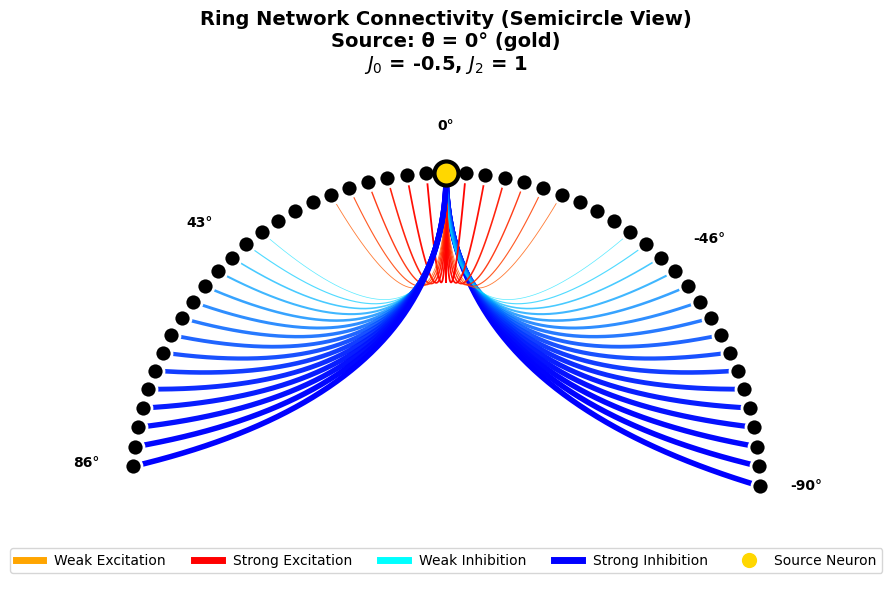

In [281]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

def interpolate_color(color1, color2, fraction):
    c1 = np.array(to_rgb(color1))
    c2 = np.array(to_rgb(color2))
    return tuple(c1 + fraction * (c2 - c1))

fig, ax = plt.subplots(figsize=(10, 6))

angles = theta_i
x_positions = np.cos(angles + np.pi/2)
y_positions = np.sin(angles + np.pi/2)

ax.scatter(x_positions, y_positions, s=150, c='black', zorder=5, edgecolors='white', linewidths=2)
source_neuron = n_number // 2

for target_idx in range(n_number):
    weight = W[source_neuron, target_idx]

    if abs(weight) < 0.01:  # Skip very weak connections
        continue

    x1, y1 = x_positions[source_neuron], y_positions[source_neuron]
    x2, y2 = x_positions[target_idx], y_positions[target_idx]
    ctrl_x, ctrl_y = 0, 0.3
    t = np.linspace(0, 1, 50)
    bez_x = (1-t)**2 * x1 + 2*(1-t)*t * ctrl_x + t**2 * x2
    bez_y = (1-t)**2 * y1 + 2*(1-t)*t * ctrl_y + t**2 * y2

    if weight > 0:
        strength_fraction = weight / np.max(W)
        color = interpolate_color('orange', 'red', strength_fraction)
        alpha = 0.6 + 0.4 * strength_fraction  # Range from 0.6 to 1.0
    else:
        strength_fraction = abs(weight) / abs(np.min(W))
        color = interpolate_color('cyan', 'blue', strength_fraction)
        alpha = 0.6 + 0.4 * strength_fraction  # Range from 0.6 to 1.0

    linewidth = abs(weight) / np.max(np.abs(W)) * 4

    ax.plot(bez_x, bez_y, color=color, alpha=alpha, linewidth=linewidth)

ax.scatter(x_positions[source_neuron], y_positions[source_neuron],
           s=300, c='gold', zorder=6, edgecolors='black', linewidths=3)
for i in [0, n_number//4, n_number//2, 3*n_number//4, n_number-1]:
    ax.text(x_positions[i]*1.15, y_positions[i]*1.15,
            f'{int(np.rad2deg(theta_i[i]))}°',
            ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.3, 1.3)
ax.set_title(f'Ring Network Connectivity (Semicircle View)\nSource: θ = 0° (gold)\n$J_0$ = {J_0}, $J_2$ = {J_2}',
             fontsize=14, fontweight='bold')

# Add legend with gradient explanation
legend_elements = [
    Line2D([0], [0], color='orange', lw=5, label='Weak Excitation'),
    Line2D([0], [0], color='red', lw=5, label='Strong Excitation'),
    Line2D([0], [0], color='cyan', lw=5, label='Weak Inhibition'),
    Line2D([0], [0], color='blue', lw=5, label='Strong Inhibition'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',
           markersize=12, label='Source Neuron')
]
ax.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10)

plt.tight_layout()
plt.show()

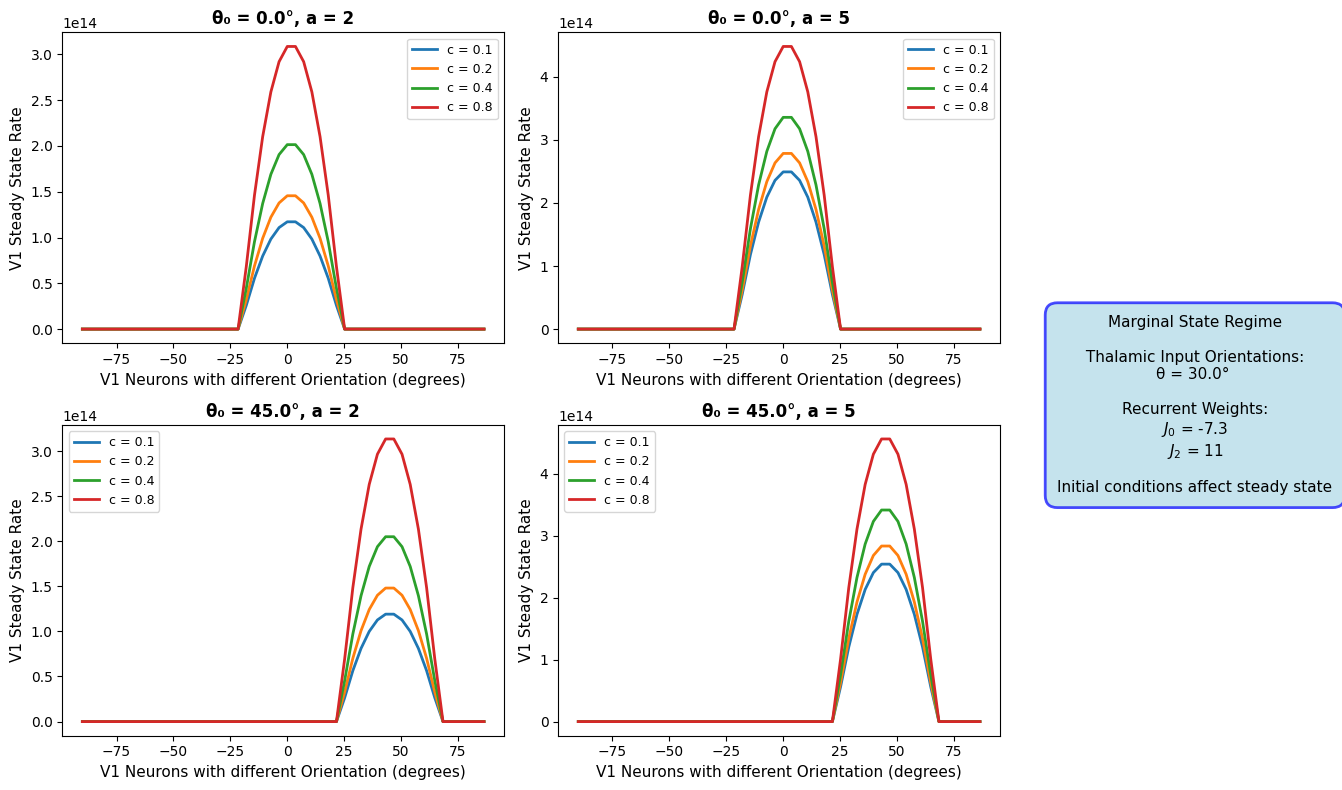

In [258]:
# Amplitude Instability regime (with huge recurrent excitation J_2 and huge recurrent inhibition J_0)
J_0, J_2 = -7.3, 11
theta_cue = np.pi/6
contrast_values = [0.1, 0.2, 0.4, 0.8]
theta_0_values = [0, np.pi/4]
a_values = [2, 5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, theta_0 in enumerate(theta_0_values):
    for idx_1, a in enumerate(a_values):
        ax = axes[idx, idx_1]

        for c in contrast_values:
            theta_i, steady_state, W = ring_model(0.1, theta_cue, 40, c, 50, 10, J_0, J_2, 0.01, 500, theta_0, a)
            ax.plot(np.rad2deg(theta_i), steady_state, label=f'c = {c}', linewidth=2)

        ax.set_xlabel('V1 Neurons with different Orientation (degrees)', fontsize=11)
        ax.set_ylabel('V1 Steady State Rate', fontsize=11)
        ax.set_title(f'θ₀ = {np.rad2deg(theta_0):.1f}°, a = {a}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)

textstr = f'Marginal State Regime\n \n Thalamic Input Orientations: \nθ = {np.rad2deg(theta_cue):.1f}° \n \nRecurrent Weights:\n$J_0$ = {J_0}\n$J_2$ = {J_2}\n\nInitial conditions affect steady state'
props = dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.7, edgecolor='blue', linewidth=2)

fig.text(1, 0.6, textstr, transform=fig.transFigure, fontsize=11,
         verticalalignment='top', horizontalalignment='center', bbox=props)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()